In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_hub
from sklearn.metrics import classification_report, confusion_matrix
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow:", tf.__version__)
print("Keras Hub :", keras_hub.__version__)
print("GPU       :", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.19.0
Keras Hub : 0.26.0
GPU       : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
!unzip "/content/drive/MyDrive/12-way script classification dataset.zip" -d /content/dataset

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/12-way script classification dataset/train_1800/punjabi/J_image_134_1.jpg  
  inflating: /content/dataset/12-way script classification dataset/train_1800/punjabi/J_image_134_14.jpg  
  inflating: /content/dataset/12-way script classification dataset/train_1800/punjabi/J_image_134_18.jpg  
  inflating: /content/dataset/12-way script classification dataset/train_1800/punjabi/J_image_134_21.jpg  
  inflating: /content/dataset/12-way script classification dataset/train_1800/punjabi/J_image_134_6.jpg  
  inflating: /content/dataset/12-way script classification dataset/train_1800/punjabi/J_image_135_16.jpg  
  inflating: /content/dataset/12-way script classification dataset/train_1800/punjabi/J_image_135_17.jpg  
  inflating: /content/dataset/12-way script classification dataset/train_1800/punjabi/J_image_135_18.jpg  
  inflating: /content/dataset/12-way script classification dataset/train_1800/punjabi/J_image_1

In [ ]:
train_dir   = "/content/dataset/12-way script classification dataset/train_1800"
test_dir    = "/content/dataset/12-way script classification dataset/test_478"

IMG_SIZE    = 224
BATCH_SIZE  = 16
NUM_CLASSES = 12
SEED        = 42
LR          = 1e-3

np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def augment(img, label):
    img = tf.image.random_brightness(img, 0.15)
    img = tf.image.random_contrast(img, 0.85, 1.15)
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_saturation(img, 0.85, 1.15)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label

def build_dataset(data_dir, training=True):
    data_dir   = Path(data_dir)
    class_dirs = sorted([d for d in data_dir.iterdir() if d.is_dir()])
    cls_names  = [d.name for d in class_dirs]
    cls_to_idx = {name: idx for idx, name in enumerate(cls_names)}

    all_paths, all_labels = [], []

    for class_dir in class_dirs:
        label = cls_to_idx[class_dir.name]
        for img_path in class_dir.glob('*'):
            if img_path.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp']:
                all_paths.append(str(img_path))
                all_labels.append(label)

    all_paths  = np.array(all_paths)
    all_labels = np.array(all_labels)

    idx        = np.random.permutation(len(all_paths))
    all_paths  = all_paths[idx]
    all_labels = all_labels[idx]

    if training:
        split      = int(0.9 * len(all_paths))
        tr_paths   = all_paths[:split]
        val_paths  = all_paths[split:]
        tr_labels  = all_labels[:split]
        val_labels = all_labels[split:]

        tr_labels_oh  = tf.keras.utils.to_categorical(tr_labels,  NUM_CLASSES)
        val_labels_oh = tf.keras.utils.to_categorical(val_labels, NUM_CLASSES)

        train_ds = (tf.data.Dataset.from_tensor_slices((tr_paths, tr_labels_oh))
                    .shuffle(len(tr_paths), seed=SEED)
                    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
                    .map(augment,             num_parallel_calls=AUTOTUNE)
                    .batch(BATCH_SIZE)
                    .prefetch(AUTOTUNE))

        val_ds   = (tf.data.Dataset.from_tensor_slices((val_paths, val_labels_oh))
                    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
                    .batch(BATCH_SIZE)
                    .prefetch(AUTOTUNE))

        return train_ds, val_ds, cls_names, tr_labels, val_labels

    else:
        labels_oh = tf.keras.utils.to_categorical(all_labels, NUM_CLASSES)

        test_ds  = (tf.data.Dataset.from_tensor_slices((all_paths, labels_oh))
                    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
                    .batch(BATCH_SIZE)
                    .prefetch(AUTOTUNE))

        return test_ds, cls_names, all_labels


train_ds, val_ds, class_names, train_labels, val_labels = build_dataset(train_dir, training=True)
test_ds,  _,      true_labels                           = build_dataset(test_dir,  training=False)

print("Classes    :", class_names)
print("Train size :", len(train_labels))
print("Val size   :", len(val_labels))
print("Test size  :", len(true_labels))

Classes    : ['assamese', 'bengali', 'english', 'gujarati', 'hindi', 'kannada', 'malayalam', 'marathi', 'odia', 'punjabi', 'tamil', 'telugu']
Train size : 19041
Val size   : 2116
Test size  : 5736


In [ ]:
# Load pretrained ViT base backbone only
backbone = keras_hub.models.ViTBackbone.from_preset(
    "vit_base_patch16_224_imagenet"
)

# Freeze backbone for phase 1
backbone.trainable = False

print("Pretrained ViT backbone loaded")
print("Backbone trainable:", backbone.trainable)

Pretrained ViT backbone loaded
Backbone trainable: False


In [ ]:
def build_model(learning_rate=LR, dropout=0.3, trainable_backbone=False):

    backbone.trainable = trainable_backbone

    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    # ViT backbone returns (batch, num_patches+1, hidden_dim)
    # index 0 is the CLS token
    x = backbone(inputs, training=False)

    # Take CLS token
    cls_token = x[:, 0, :]

    # Classification head
    x = layers.LayerNormalization()(cls_token)
    x = layers.Dense(512, activation='gelu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(256, activation='gelu')(x)
    x = layers.Dropout(dropout * 0.5)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = keras.Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


model = build_model()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vi_t_backbone (ViTBackbone)     │ (None, 197, 768)       │    85,798,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ get_item (GetItem)              │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 768)            │         1,536 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       393,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 12)             │         3,084 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 86,330,380 (329.32 MB)

 Trainable params: 530,700 (2.02 MB)

 Non-trainable params: 85,799,680 (327.30 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

def get_callbacks(name):
    return [
        EarlyStopping(
            monitor='val_accuracy',
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        ModelCheckpoint(
            name,
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-8,
            verbose=1
        )
    ]

print("Callbacks ready")

Callbacks ready


In [ ]:
print("Phase 1: Training classification head only")
print("=" * 55)

history1 = model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    callbacks=get_callbacks('phase1_best.keras'),
    verbose=1
)

print(f"\nPhase 1 best val accuracy: {max(history1.history['val_accuracy'])*100:.2f}%")

Phase 1: Training classification head only
Epoch 1/10
1191/1191 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.3620 - loss: 1.9858
Epoch 1: val_accuracy improved from None to 0.51654, saving model to phase1_best.keras

Epoch 1: finished saving model to phase1_best.keras
1191/1191 ━━━━━━━━━━━━━━━━━━━━ 284s 223ms/step - accuracy: 0.4307 - loss: 1.7056 - val_accuracy: 0.5165 - val_loss: 1.3738 - learning_rate: 0.0010
Epoch 2/10
1190/1191 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.5518 - loss: 1.2802
Epoch 2: val_accuracy improved from 0.51654 to 0.57987, saving model to phase1_best.keras

Epoch 2: finished saving model to phase1_best.keras
1191/1191 ━━━━━━━━━━━━━━━━━━━━ 254s 213ms/step - accuracy: 0.5514 - loss: 1.2925 - val_accuracy: 0.5799 - val_loss: 1.2018 - learning_rate: 0.0010
Epoch 3/10
1190/1191 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.5934 - loss: 1.1678
Epoch 3: val_accuracy improved from 0.57987 to 0.59924, saving model to phase1_best.keras

Epoch 3: finished s

In [ ]:
print("Phase 2: Fine-tuning backbone last layers")
print("=" * 55)

# Rebuild with backbone unfrozen
model = build_model(
    learning_rate=5e-5,
    dropout=0.3,
    trainable_backbone=True
)

# Freeze all backbone layers first
for layer in backbone.layers:
    layer.trainable = False

# Unfreeze last 3 transformer encoder layers
for layer in backbone.layers:
    if any(f'_{i}' in layer.name for i in ['9', '10', '11']):
        layer.trainable = True

# Recompile after changing trainable
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model.fit(
    train_ds,
    epochs=15,
    validation_data=val_ds,
    callbacks=get_callbacks('phase2_best.keras'),
    verbose=1
)

print(f"\nPhase 2 best val accuracy: {max(history2.history['val_accuracy'])*100:.2f}%")

Phase 2: Fine-tuning backbone last layers
Epoch 1/15
1191/1191 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.1880 - loss: 2.5825
Epoch 1: val_accuracy improved from None to 0.45085, saving model to phase2_best.keras

Epoch 1: finished saving model to phase2_best.keras
1191/1191 ━━━━━━━━━━━━━━━━━━━━ 281s 222ms/step - accuracy: 0.2564 - loss: 2.2923 - val_accuracy: 0.4509 - val_loss: 1.6649 - learning_rate: 5.0000e-05
Epoch 2/15
1190/1191 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.3934 - loss: 1.7877
Epoch 2: val_accuracy improved from 0.45085 to 0.52836, saving model to phase2_best.keras

Epoch 2: finished saving model to phase2_best.keras
1191/1191 ━━━━━━━━━━━━━━━━━━━━ 256s 215ms/step - accuracy: 0.4154 - loss: 1.7296 - val_accuracy: 0.5284 - val_loss: 1.4233 - learning_rate: 5.0000e-05
Epoch 3/15
1190/1191 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.4758 - loss: 1.5377
Epoch 3: val_accuracy improved from 0.52836 to 0.57136, saving model to phase2_best.keras

Epoch 3: fin

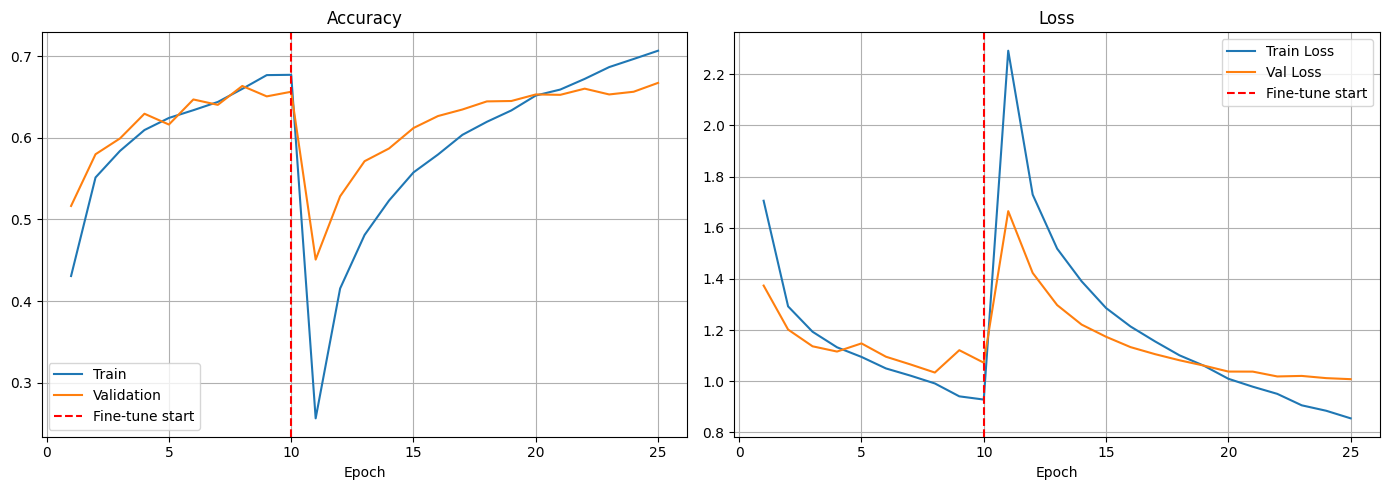

In [ ]:
def plot_curves(h1, h2):
    acc   = h1.history['accuracy']     + h2.history['accuracy']
    val   = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss  = h1.history['loss']         + h2.history['loss']
    vloss = h1.history['val_loss']     + h2.history['val_loss']
    ep    = range(1, len(acc) + 1)
    split = len(h1.history['accuracy'])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(ep, acc,  label='Train')
    axes[0].plot(ep, val,  label='Validation')
    axes[0].axvline(x=split, color='red', linestyle='--', label='Fine-tune start')
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(ep, loss,  label='Train Loss')
    axes[1].plot(ep, vloss, label='Val Loss')
    axes[1].axvline(x=split, color='red', linestyle='--', label='Fine-tune start')
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150)
    plt.show()

plot_curves(history1, history2)

In [ ]:
print("Evaluating on test set...")
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"\nTest Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_acc*100:.2f}%")

Evaluating on test set...
359/359 ━━━━━━━━━━━━━━━━━━━━ 70s 196ms/step - accuracy: 0.5851 - loss: 1.2176

Test Loss    : 1.2176
Test Accuracy: 58.51%


In [ ]:
y_pred_probs = model.predict(test_ds, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = true_labels

print("\nClassification Report:")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

cm        = confusion_matrix(y_true, y_pred)
class_acc = cm.diagonal() / cm.sum(axis=1)

print("Class-wise Accuracy:")
print("-" * 35)
for name, acc in zip(class_names, class_acc):
    print(f"  {name:20s}: {acc*100:.2f}%")
print("-" * 35)
print(f"  Mean Accuracy: {class_acc.mean()*100:.2f}%")

359/359 ━━━━━━━━━━━━━━━━━━━━ 77s 200ms/step

Classification Report:
              precision    recall  f1-score   support

    assamese     0.5747    0.5795    0.5771       478
     bengali     0.6248    0.6967    0.6588       478
     english     0.6241    0.5523    0.5860       478
    gujarati     0.6369    0.6715    0.6538       478
       hindi     0.4824    0.5460    0.5123       478
     kannada     0.4701    0.5418    0.5034       478
   malayalam     0.5775    0.6234    0.5996       478
     marathi     0.6104    0.4163    0.4950       478
        odia     0.6818    0.7218    0.7012       478
     punjabi     0.6257    0.6715    0.6478       478
       tamil     0.5801    0.5377    0.5581       478
      telugu     0.5553    0.4623    0.5046       478

    accuracy                         0.5851      5736
   macro avg     0.5870    0.5851    0.5831      5736
weighted avg     0.5870    0.5851    0.5831      5736

Class-wise Accuracy:
-----------------------------------
  assame

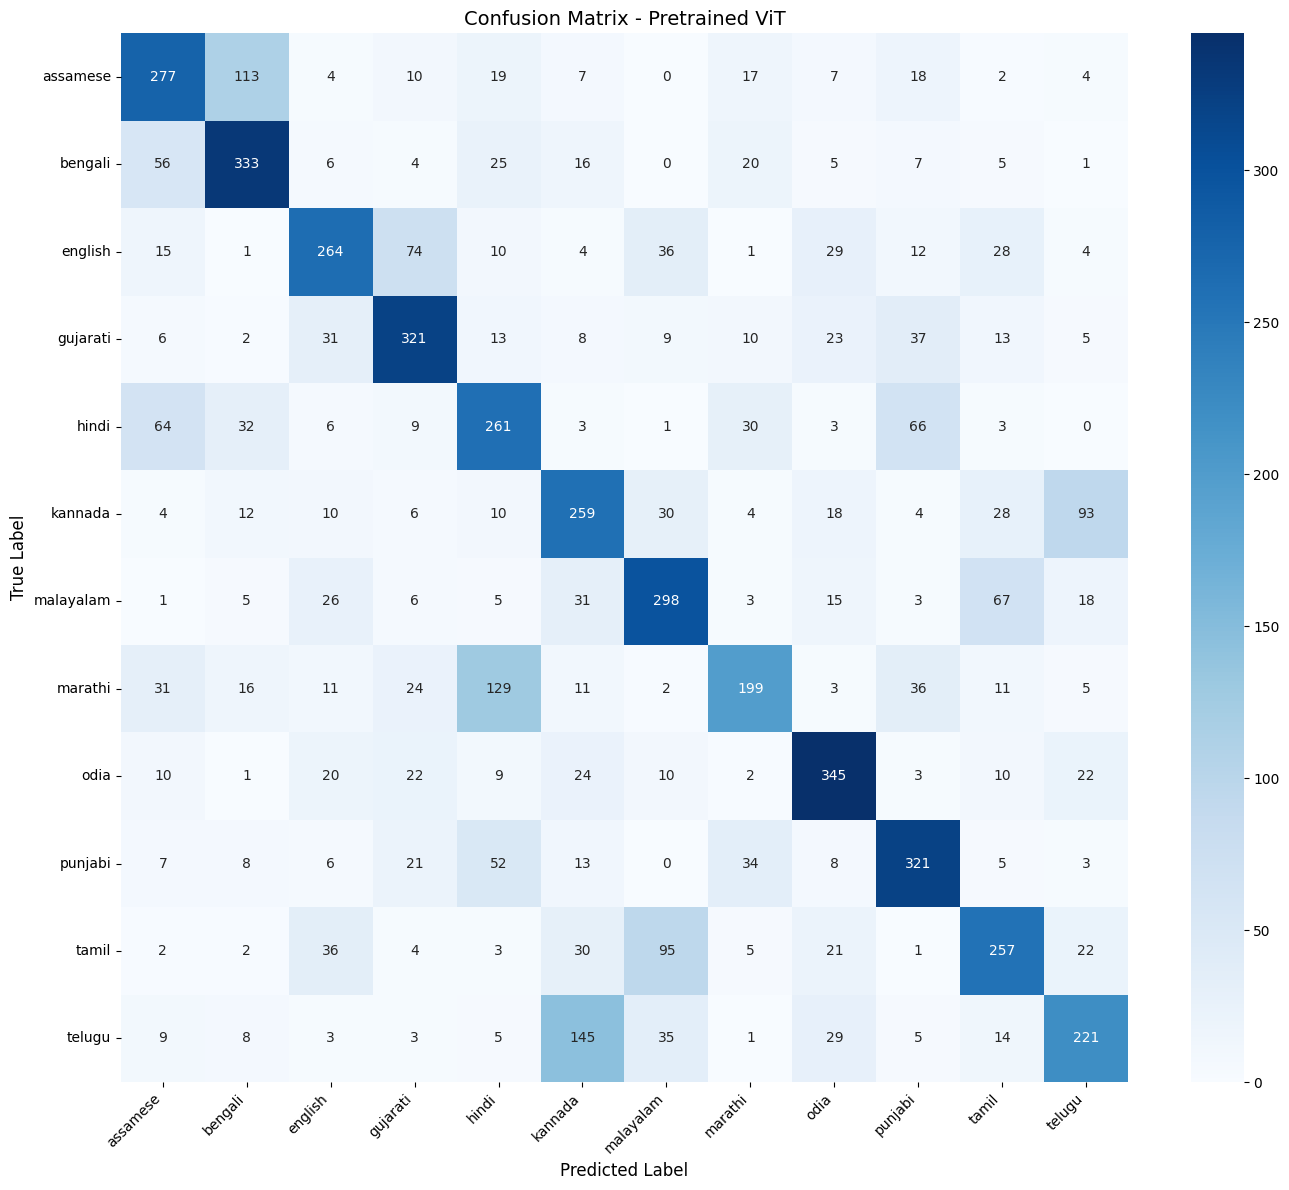

In [ ]:
plt.figure(figsize=(14, 12))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Confusion Matrix - Pretrained ViT', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [ ]:
configs = [
    {'lr': 3e-4, 'dropout': 0.2, 'trainable': False},
    {'lr': 1e-4, 'dropout': 0.3, 'trainable': False},
    {'lr': 5e-5, 'dropout': 0.2, 'trainable': True},
]

results = []

for i, cfg in enumerate(configs):
    print(f"\nConfig {i+1}: {cfg}")
    print("-" * 45)

    m = build_model(
        learning_rate=cfg['lr'],
        dropout=cfg['dropout'],
        trainable_backbone=cfg['trainable']
    )

    hist = m.fit(
        train_ds,
        epochs=8,
        validation_data=val_ds,
        callbacks=get_callbacks(f'tune_{i+1}.keras'),
        verbose=1
    )

    best_val = max(hist.history['val_accuracy'])
    results.append({'config': cfg, 'val_acc': best_val, 'model': m})
    print(f"Config {i+1} best val acc: {best_val*100:.2f}%")

best       = max(results, key=lambda x: x['val_acc'])
best_model = best['model']
print("\nBest config :", best['config'])
print("Best val acc:", f"{best['val_acc']*100:.2f}%")


Config 1: {'lr': 0.0003, 'dropout': 0.2, 'trainable': False}
---------------------------------------------
Epoch 1/8
1191/1191 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.3527 - loss: 1.9662
Epoch 1: val_accuracy improved from None to 0.54679, saving model to tune_1.keras

Epoch 1: finished saving model to tune_1.keras
1191/1191 ━━━━━━━━━━━━━━━━━━━━ 285s 225ms/step - accuracy: 0.4393 - loss: 1.6613 - val_accuracy: 0.5468 - val_loss: 1.3001 - learning_rate: 3.0000e-04
Epoch 2/8
1190/1191 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.5749 - loss: 1.2269
Epoch 2: val_accuracy improved from 0.54679 to 0.61484, saving model to tune_1.keras

Epoch 2: finished saving model to tune_1.keras
1191/1191 ━━━━━━━━━━━━━━━━━━━━ 258s 217ms/step - accuracy: 0.5819 - loss: 1.2115 - val_accuracy: 0.6148 - val_loss: 1.1483 - learning_rate: 3.0000e-04
Epoch 3/8
1190/1191 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.6356 - loss: 1.0603
Epoch 3: val_accuracy improved from 0.61484 to 0.64650, savi

359/359 ━━━━━━━━━━━━━━━━━━━━ 70s 195ms/step - accuracy: 0.8236 - loss: 0.6601

Final Test Accuracy: 82.36%
359/359 ━━━━━━━━━━━━━━━━━━━━ 76s 199ms/step

Final Class-wise Accuracy:
-----------------------------------
  assamese            : 70.29%
  bengali             : 81.38%
  english             : 85.36%
  gujarati            : 89.96%
  hindi               : 64.23%
  kannada             : 89.75%
  malayalam           : 88.28%
  marathi             : 72.38%
  odia                : 95.61%
  punjabi             : 92.89%
  tamil               : 77.41%
  telugu              : 80.75%
-----------------------------------
  Mean Accuracy: 82.36%

Full Classification Report:
              precision    recall  f1-score   support

    assamese     0.6843    0.7029    0.6935       478
     bengali     0.6959    0.8138    0.7502       478
     english     0.8850    0.8536    0.8690       478
    gujarati     0.9130    0.8996    0.9062       478
       hindi     0.7852    0.6423    0.7066       478

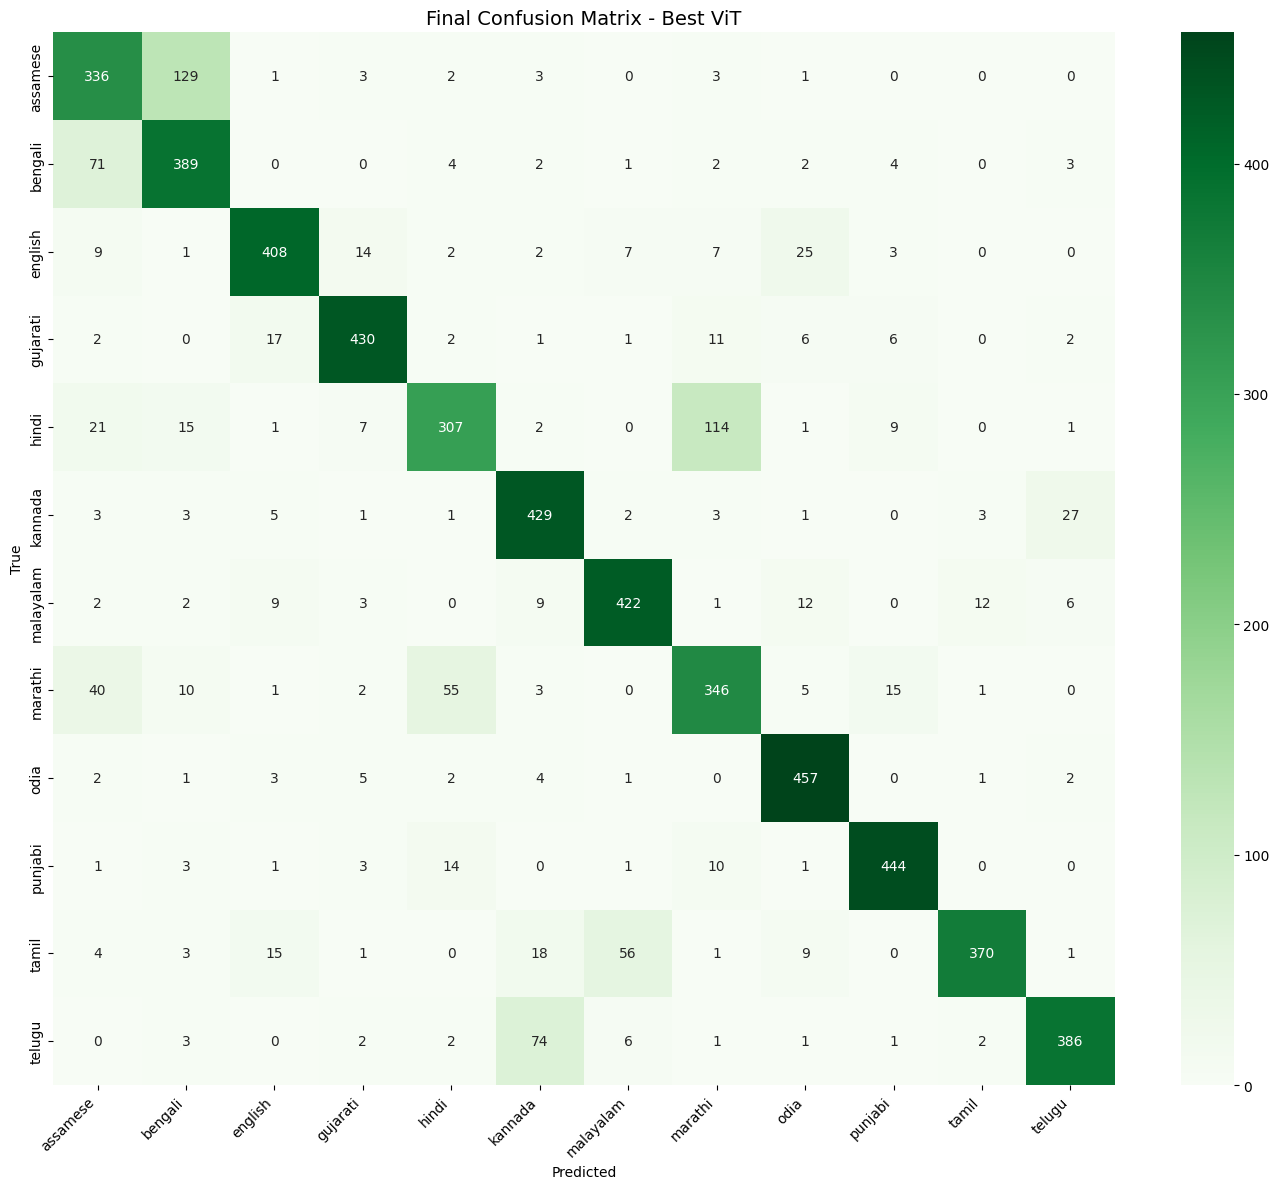

In [ ]:
test_loss, test_acc = best_model.evaluate(test_ds, verbose=1)
print(f"\nFinal Test Accuracy: {test_acc*100:.2f}%")

y_pred_final = np.argmax(best_model.predict(test_ds, verbose=1), axis=1)
y_true_final = true_labels

cm_final    = confusion_matrix(y_true_final, y_pred_final)
class_acc_f = cm_final.diagonal() / cm_final.sum(axis=1)

print("\nFinal Class-wise Accuracy:")
print("-" * 35)
for name, acc in zip(class_names, class_acc_f):
    print(f"  {name:20s}: {acc*100:.2f}%")
print("-" * 35)
print(f"  Mean Accuracy: {class_acc_f.mean()*100:.2f}%")

print("\nFull Classification Report:")
print(classification_report(y_true_final, y_pred_final, target_names=class_names, digits=4))

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm_final,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Final Confusion Matrix - Best ViT', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('final_confusion_matrix.png', dpi=150)
plt.show()